# Implementation

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm, null_space

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import UnitaryGate
from qiskit.quantum_info import DensityMatrix
from qiskit_aer import AerSimulator
from qiskit.quantum_info import DensityMatrix, Kraus
from qiskit import QuantumCircuit, transpile

import import_ipynb
# from validation_and_helpers import load_run
from E_in_eigener_file import calculate_heom_propagator
from non_markov_circuit import propagate_memory_shots, arnoldi, dilate, propagate_memory_shots, propagate_memory_density_matrix, propagate_memory_classical

# Parameter

In [5]:
# ---- physical constants (energies in cm^-1, time tau = 2*pi*c*t in cm) ----
_C_CM = 2.99792458e10                    # speed of light [cm/s]
FS_TO_CM = 1e-15 * 2 * np.pi * _C_CM     # tau[cm] per t[fs]
KB_CM = 0.6950348004                     # Boltzmann constant [cm^-1/K]

N = 4                                    # 4-site (Seneviratne eq. 30) or 7-site FMO

if N == 4:
    H_FMO = np.array([[12375.0, -87.7,   5.5,  -5.9],
                      [-87.7, 12495.0,  30.8,   8.2],
                      [5.5,      30.8, 12175.0, -53.4],
                      [-5.9,      8.2, -53.4, 12285.0]])
elif N == 7:
    H_FMO = np.array([[1410.0, -87.7, 5.5, -5.9, 6.7, -13.7, -9.9],
                      [-87.7, 1530.0, 30.8, 8.2, 0.7, 11.8, 4.3],
                      [5.5, 30.8, 1210.0, -53.5, -2.2, -9.6, 6.0],
                      [-5.9, 8.2, -53.5, 1320.0, -70.7, -17.0, -63.3],
                      [6.7, 0.7, -2.2, -70.7, 1480.0, 81.1, -1.3],
                      [-13.7, 11.8, -9.6, -17.0, 81.1, 1630.0, 39.7],
                      [-9.9, 4.3, 6.0, -63.3, -1.3, 39.7, 1440.0]])
else:
    raise ValueError('N must be 4 or 7')

H_FMO = H_FMO - np.trace(H_FMO) / N * np.eye(N)
LAM_FMO, GAM_FMO, T_FMO = 3.0, 80, 300.0

# Bundled once and splatted into every method below, so HEOM and Lindblad are
# guaranteed to run on identical parameters.
MODEL = dict(H=H_FMO, lam=LAM_FMO, gamma=GAM_FMO, T_K=T_FMO,
             KB_CM=KB_CM, FS_TO_CM=FS_TO_CM)

K = 25
N = 4 
dt_fs = 10
t_fs = np.arange(0.0, 1001.0, dt_fs)      
HEOM_depth = 3

In [13]:
# Initialisiere globales Dictionary (falls noch nicht vorhanden)
if 'out_B' not in globals():
    out_B = {}

M_KRYLOV = 64

# Calculate

### Startzustände

In [7]:
# 1. Propagator E und die berechneten Kurzzeit-Karten holen
E, K, maps = calculate_heom_propagator(dt_fs, HEOM_depth=HEOM_depth, K_heom=K, N=N, **MODEL)

# 2. Vektorisierter Startzustand rho(0)
rho0_vec = np.zeros(N * N, complex)
rho0_vec[0] = 1.0  # Anregung auf Site 1

# 3. Exakte Historie der ersten K Schritte via L(t) * rho0 berechnen
rho_history = [maps[i] @ rho0_vec for i in range(K)]

# 4. Physikalischen Super-Vektor X0 zusammensetzen:
# rho(t_{K-1}) liegt ganz oben (Index 0), rho(t_0) ganz unten
X0 = np.concatenate(rho_history[::-1])

### Exaktes Ergebnis

In [ ]:
D_dim = N * N
n_steps_total = len(t_fs) - 1
exact_pops = np.zeros((n_steps_total + 1, N))

# Die ersten K Schritte (0 bis K-1) direkt aus der berechneten Historie befüllen:
for i in range(K):
    exact_pops[i, :] = np.real(np.diag(rho_history[i].reshape((N, N), order='F')))

# Ab Schritt K propagieren wir den Zustand klassisch mit E weiter:
X_curr = X0_phys.copy()
for t in range(K, n_steps_total + 1):
    X_curr = E @ X_curr
    exact_pops[t, :] = np.real(np.diag(X_curr[:D_dim].reshape((N, N), order='F')))

res = {
    'HEOM': {
        'E': E,
        'K': K,
        'pops': exact_pops,
        'rho': [r.reshape((N, N), order='F') for r in rho_history]
    }
}
print("Referenz von t=0 bis t=1000 fs vollständig aufgebaut!")

Exakte klassische Referenz für HEOM erfolgreich berechnet! (Shape: (101, 4))


### Shots

In [9]:
name = 'HEOM'

pops, qc, info = propagate_memory_shots(E, X0, len(t_fs) - K, M_KRYLOV, N)
out_B[name] = (pops, qc, info)

full_reg = E.shape[0]
print(f"{name:14s} register {full_reg} -> {info['m']} (Krylov), {info['n_qubits']} qubits, depth {qc.depth()}")
print(f"{'':14s} ||H_m|| = {info['norm_Hm']:.4f}, p_success = {info['p_success']:.3e} ({1 / info['p_success']:.1f} shots/sample), "
      f"naive would be {(1 / np.linalg.norm(E, 2) ** 2) ** (len(t_fs) - K):.1e}")
print(f"{'':14s} vs stored result: {np.abs(pops - res[name]['pops'][K - 1:]).max():.2e}\n")

Zeitschritt 76/76
HEOM           register 400 -> 32 (Krylov), 6 qubits, depth 228
               ||H_m|| = 1.0183, p_success = 2.560e-02 (39.1 shots/sample), naive would be 1.3e-23
               vs stored result: 3.43e-02



### Density Matrix

In [ ]:
source_name = 'HEOM'
entry_name = 'HEOM (DM)'


# 2. Den echten physikalischen Super-Vektor X0 aufbauen
rho0_vec = np.zeros(N * N, complex)
rho0_vec[0] = 1.0  # Anregung startet auf Site 1

# Die echten Zustände der ersten K Schritte berechnen
rho_history = [maps[i] @ rho0_vec for i in range(K)]

# Zum Vektor X0 zusammensetzen (ältester Zustand unten)
X0_phys = np.concatenate(rho_history[::-1])

# 3. Aufruf der deterministischen Dichtematrix-Funktion mit dem KORREKTEN X0_phys
pops, qc, info = propagate_memory_density_matrix(E, X0_phys, len(t_fs) - K, M_KRYLOV, N)
out_B[entry_name] = (pops, qc, info)

full_reg = E.shape[0]
print(f"{entry_name:14s} register {full_reg} -> {info['m']} (Krylov), {info['n_qubits']} qubits, depth {qc.depth()}")
print(f"{'':14s} ||H_m|| = {info['norm_Hm']:.4f}, p_success = {info.get('p_success', 1.0):.3e} ({1 / info.get('p_success', 1.0):.1f} shots/sample), "
      f"naive would be {(1 / np.linalg.norm(E, 2) ** 2) ** (len(t_fs) - K):.1e}")
print(f"{'':14s} vs stored result: {np.abs(pops - res[source_name]['pops'][K - 1:]).max():.2e}\n")

### Klassisch, d.h. ohne quantum circuit

In [ ]:
entry_name = 'HEOM (Classical Krylov)'

# Aufruf
pops_class, _, info_class = propagate_memory_classical(E, X0_phys, len(t_fs) - K, M_KRYLOV, N)
out_B[entry_name] = (pops_class, None, info_class)

# Vergleich mit der gespeicherten Referenz
print(f"Max Abweichung zur Referenz: {np.abs(pops_class - res['HEOM']['pops'][K - 1:]).max():.2e}")

# Plotting

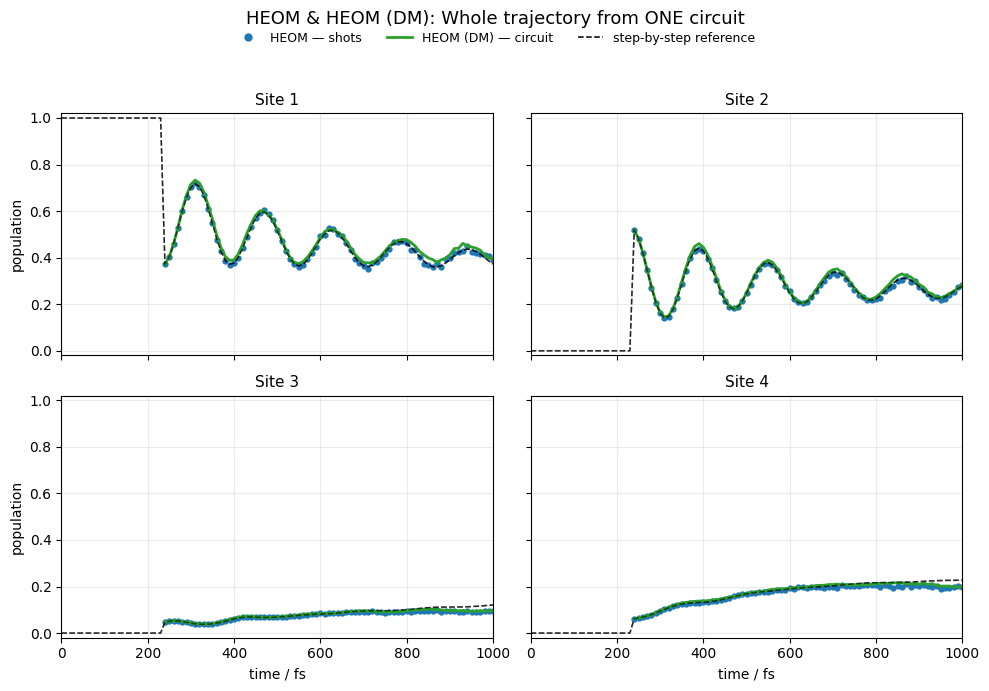

wrote pictures/single_grid_HEOM_HEOM_DM_N4.png


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- AUSWAHL: Einfach gewünschte Methoden ein-/auskommentieren ---
plot_methods = [
    'HEOM',
    'HEOM (DM)',
    'HEOM (Classical Krylov)',
    # 'Path integral',
]

# Farb-Mapping
col = {
    'HEOM': '#1f77b4',
    'HEOM (DM)': '#2ca02c',
    'HEOM (Classical Krylov)': '#ff7f0e',
    # 'Path integral': '#d62728'
}

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)

for site, ax in enumerate(axes.flat):
    for name in plot_methods:
        if name not in out_B:
            continue
        
        # Basis-Name ('HEOM' oder 'Path integral') für Referenzdaten ermitteln
        ref_key = 'HEOM' if 'HEOM' in name else 'Path integral'
        K = res[ref_key]['K']
        
        # Stil-Unterscheidung je nach Methode
        if '(DM)' in name:
            ax.plot(t_fs[K - 1:], out_B[name][0][:, site], color=col[name], 
                    ls='-', lw=2.0, label=name)
        elif 'Classical' in name:
            ax.plot(t_fs[K - 1:], out_B[name][0][:, site], color=col[name], 
                    ls=':', lw=2.2, label=name)
        else:
            ax.plot(t_fs[K - 1:], out_B[name][0][:, site], color=col[name], 
                    marker='o', ls='none', markersize=3.5, label=name)
        
        # Zugehörige Referenz
        ax.plot(t_fs, res[ref_key]['pops'][:, site], color='k', ls='--', lw=1.1, alpha=0.6)
        
    ax.set_title(f'Site {site + 1}', fontsize=11)
    ax.set_xlim(0, t_fs[-1])
    ax.set_ylim(-0.02, 1.02)
    ax.grid(alpha=0.25)
    if site >= 2: 
        ax.set_xlabel('time / fs')
    if site % 2 == 0: 
        ax.set_ylabel('population')

# Dynamische Legende aufbauen
handles = []
for name in plot_methods:
    if name in out_B:
        if '(DM)' in name:
            handles.append(Line2D([], [], color=col[name], ls='-', lw=2.0, 
                                  label=f'{name} — circuit'))
        elif 'Classical' in name:
            handles.append(Line2D([], [], color=col[name], ls=':', lw=2.2, 
                                  label=f'{name} — exact Krylov'))
        else:
            handles.append(Line2D([], [], color=col[name], marker='o', ls='none', markersize=5, 
                                  label=f'{name} — shots'))

# Referenz-Eintrag einmalig hinzufügen
if handles:
    handles.append(Line2D([], [], color='k', ls='--', lw=1.1, label='step-by-step reference'))

fig.legend(handles=handles, loc='upper center', ncol=len(handles), frameon=False, fontsize=9,
           bbox_to_anchor=(0.5, 0.965))

title_str = " & ".join([n for n in plot_methods if n in out_B])
fig.suptitle(f'{title_str}: Whole trajectory comparison', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.93])

filename_suffix = "_".join([n.replace(" ", "_").replace("(", "").replace(")", "") for n in plot_methods if n in out_B])
fig.savefig(f'pictures/single_grid_{filename_suffix}_N{N}.png', dpi=200)
plt.show()
print(f'wrote pictures/single_grid_{filename_suffix}_N{N}.png')

In [12]:
source_name = 'HEOM'
E, K = res[source_name]['E'], res[source_name]['K']
X0 = np.concatenate([res[source_name]['rho'][i].flatten(order='F') for i in range(K)][::-1])
ref_pops = res[source_name]['pops'][K - 1:]

# 10 eindeutige Integer-Werte zwischen 32 und 64 generieren
m_values = np.unique(np.linspace(32, 64, 10, dtype=int))
errors = []
success_probs = []

print(f"{'M_KRYLOV':<10} | {'Max Error vs Ref':<18} | {'p_success':<12} | {'||H_m||':<10}")
print("-" * 58)

for m_val in m_values:
    # Simulation mit aktuellem M_KRYLOV ausführen
    pops, qc, info = propagate_memory_density_matrix(E, X0, len(t_fs) - K, int(m_val), d)
    
    # Maximalen absoluten Fehler zur Referenz berechnen
    err = np.abs(pops - ref_pops).max()
    errors.append(err)
    success_probs.append(info.get('p_success', 1.0))
    
    print(f"{m_val:<10d} | {err:<18.2e} | {info.get('p_success', 1.0):<12.3e} | {info['norm_Hm']:<10.4f}")

# Optional: Fehlerverlauf plotten
fig, ax1 = plt.subplots(figsize=(7, 4.5))

col_err = '#1f77b4'
col_p = '#d62728'

ax1.semilogy(m_values, errors, color=col_err, marker='o', lw=1.8, label='Max Error')
ax1.set_xlabel('Krylov Dimension $m$', fontsize=11)
ax1.set_ylabel('Max Absolute Error vs Reference', color=col_err, fontsize=11)
ax1.tick_params(axis='y', labelcolor=col_err)
ax1.grid(True, which='both', alpha=0.25)

# Zweite y-Achse für Erfolgswahrscheinlichkeit
ax2 = ax1.twinx()
ax2.semilogy(m_values, success_probs, color=col_p, marker='s', ls='--', lw=1.5, label='p_success')
ax2.set_ylabel('Success Probability $p_{\mathrm{total}}$', color=col_p, fontsize=11)
ax2.tick_params(axis='y', labelcolor=col_p)

plt.title(f'{source_name}: Error vs Krylov Dimension $m$', fontsize=12)
fig.tight_layout()
plt.show()

M_KRYLOV   | Max Error vs Ref   | p_success    | ||H_m||   
----------------------------------------------------------


<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_253392/3907300571.py:40: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel('Success Probability $p_{\mathrm{total}}$', color=col_p, fontsize=11)
/tmp/ipykernel_253392/3907300571.py:40: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel('Success Probability $p_{\mathrm{total}}$', color=col_p, fontsize=11)


NameError: name 'd' is not defined

# Saved

-------------Originaler Aufruf de E tensors---------------

N = 4
run = load_run(f'data/run_N{N}.npz')
d, D, t_fs = run['d'], run['d'] ** 2, run['t_fs']
res = run['res']
print(f'N = {N},  d = {d},  reference run loaded')


---------------Pfad integral aufruf----------------

name = 'Path integral'

E, K = res[name]['E'], res[name]['K']
X0 = np.concatenate([res[name]['rho'][i].flatten(order='F') for i in range(K)][::-1])

pops, qc, info = propagate_memory_shots(E, X0, len(t_fs) - K, M_KRYLOV, d)
out_B[name] = (pops, qc, info)

full_reg = E.shape[0]
print(f"{name:14s} register {full_reg} -> {info['m']} (Krylov), {info['n_qubits']} qubits, depth {qc.depth()}")
print(f"{'':14s} ||H_m|| = {info['norm_Hm']:.4f}, p_success = {info['p_success']:.3e} ({1 / info['p_success']:.1f} shots/sample), "
      f"naive would be {(1 / np.linalg.norm(E, 2) ** 2) ** (len(t_fs) - K):.1e}")
print(f"{'':14s} vs stored result: {np.abs(pops - res[name]['pops'][K - 1:]).max():.2e}\n")